<a href="https://colab.research.google.com/github/lelcash/Flower-Detection/blob/main/Flower_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Flower Recognition CNN

This project implements a Convolutional Neural Network (CNN) to automatically identify and classify images of flowers into five distinct categories. It features data augmentation and modular code structure to optimize model accuracy and prevent overfitting.

In [1]:
!apt-get install graphviz -y > /dev/null
!pip install pydot gradio > /dev/null

# 3. Import Machine Learning libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import plot_model
import matplotlib.pyplot as plt
import numpy as np
import pathlib
import kagglehub

# Set random seed
tf.random.set_seed(123)
print("TensorFlow Version:", tf.__version__)
print("Setup Complete!")

TensorFlow Version: 2.20.0
Setup Complete!


Data Loading Function

In [3]:
# Download latest version
path = kagglehub.dataset_download("alxmamaev/flowers-recognition")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'flowers-recognition' dataset.
Path to dataset files: /kaggle/input/flowers-recognition


#Load preprocess data:



In [8]:
import os

#Finding the folder containing the 5 classes
correct_path = "/kaggle/input/flowers-recognition/flowers"


dataset_path = pathlib.Path(correct_path)
print(f"Dataset securely located at: {dataset_path}")


def load_and_preprocess_data(data_dir, batch_size=128, img_size=(150, 150)):
    """Loads images from the correct Kaggle folder and splits them 80/20."""
    train_ds = tf.keras.utils.image_dataset_from_directory(
        data_dir,
        validation_split=0.2,
        subset="training",
        seed=42,
        image_size=img_size,
        batch_size=batch_size
    )

    val_ds = tf.keras.utils.image_dataset_from_directory(
        data_dir,
        validation_split=0.2,
        subset="validation",
        seed=42,
        image_size=img_size,
        batch_size=batch_size
    )

    class_names = train_ds.class_names
    AUTOTUNE = tf.data.AUTOTUNE
    train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
    val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

    return train_ds, val_ds, class_names

# --- Execute the Data Loader ---
batch_size = 128
img_height = 150
img_width = 150

print("\n2. Loading Data into Keras...")
train_ds, val_ds, class_names = load_and_preprocess_data(dataset_path, batch_size, (img_height, img_width))
print(f"\nSUCCESS! Classes identified: {class_names}")

Dataset securely located at: /kaggle/input/flowers-recognition/flowers

2. Loading Data into Keras...
Found 4317 files belonging to 5 classes.
Using 3454 files for training.
Found 4317 files belonging to 5 classes.
Using 863 files for validation.

SUCCESS! Classes identified: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']


#The Kaggle Model Architecture

In [9]:
def build_kaggle_cnn(img_height, img_width, num_classes):
    """
    Constructs the specific CNN architecture adapted from the Kaggle Flower Recognition
    notebook, featuring 4 Conv2D layers and Data Augmentation.
    """
    model = models.Sequential([
        # Data Augmentation (Matching the Kaggle ImageDataGenerator params)
        layers.RandomFlip("horizontal", input_shape=(img_height, img_width, 3)),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.RandomTranslation(height_factor=0.2, width_factor=0.2),

        # Input Layer: Rescale pixel values
        layers.Rescaling(1./255),

        # Layer 1
        layers.Conv2D(filters=32, kernel_size=(5,5), padding='Same', activation='relu'),
        layers.MaxPooling2D(pool_size=(2,2)),

        # Layer 2
        layers.Conv2D(filters=64, kernel_size=(3,3), padding='Same', activation='relu'),
        layers.MaxPooling2D(pool_size=(2,2), strides=(2,2)),

        # Layer 3
        layers.Conv2D(filters=96, kernel_size=(3,3), padding='Same', activation='relu'),
        layers.MaxPooling2D(pool_size=(2,2), strides=(2,2)),

        # Layer 4
        layers.Conv2D(filters=96, kernel_size=(3,3), padding='Same', activation='relu'),
        layers.MaxPooling2D(pool_size=(2,2), strides=(2,2)),

        # Fully Connected Classifier
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])

    # Adam Optimizer with a starting learning rate of 0.001
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
                  metrics=['accuracy'])
    return model

#Plotting

In [10]:
def plot_training_results(history, epochs):
    """Visualizes the training and validation accuracy/loss over time."""
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs_range = range(len(acc)) # dynamic range based on actual run

    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.show()

#The Main Training Loop

1. Loading Data...
Found 4317 files belonging to 5 classes.
Using 3454 files for training.
Found 4317 files belonging to 5 classes.
Using 863 files for validation.

2. Building Model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



3. Training Model (This will take a few minutes)...
Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 31s 368ms/step - accuracy: 0.3437 - loss: 1.4837 - val_accuracy: 0.4647 - val_loss: 1.2109 - learning_rate: 0.0010
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - accuracy: 0.5116 - loss: 1.2017 - val_accuracy: 0.5435 - val_loss: 1.1379 - learning_rate: 0.0010
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - accuracy: 0.5657 - loss: 1.0839 - val_accuracy: 0.5817 - val_loss: 1.0497 - learning_rate: 0.0010
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - accuracy: 0.6074 - loss: 1.0007 - val_accuracy: 0.5829 - val_loss: 1.0413 - learning_rate: 0.0010
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 107ms/step - accuracy: 0.6343 - loss: 0.9559 - val_accuracy: 0.6118 - val_loss: 0.9555 - learning_rate: 0.0010
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step - accuracy: 0.6320 - loss: 0.9395 - val_accuracy: 0.6605 - val_loss: 0.8722 - learning_rate: 0.0010
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━

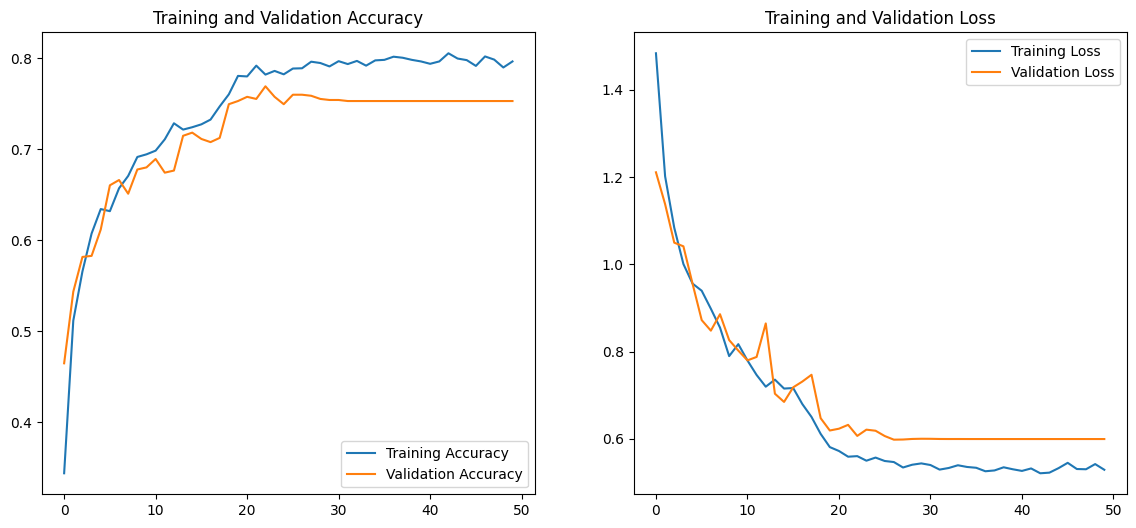

In [13]:
import pathlib
from tensorflow.keras.callbacks import ReduceLROnPlateau

# --- Configuration ---
# CHANGE THIS PATH to match your Google Drive folder structure!
# The dataset is now downloaded from Kaggle, so we ensure the path is correct.
dataset_path = pathlib.Path("/kaggle/input/flowers-recognition/flowers")

batch_size = 128
img_height = 150
img_width = 150
epochs = 50

# --- Execute Pipeline ---
print("1. Loading Data...")
train_ds, val_ds, class_names = load_and_preprocess_data(dataset_path, batch_size, (img_height, img_width))

print("\n2. Building Model...")
model = build_kaggle_cnn(img_height, img_width, len(class_names))

print("\n3. Training Model (This will take a few minutes)...")
# Learning Rate Annealer (from the Kaggle Notebook)
red_lr = ReduceLROnPlateau(monitor='val_accuracy', patience=3, verbose=1, factor=0.1)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=[red_lr] # Added the callback here
)

print("\n4. Plotting Results...")
plot_training_results(history, epochs)

#The Live Web App